### **Name : Vishesh Kumar**  
### **CU24250050**  
### **Sec: B**  
### **Roll No : 69**  
### **Computer Vision**  
### **Labsheet - 8**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
cap = cv2.VideoCapture("video1.mp4")

if not cap.isOpened():
    print("Error: Video not found")
else:
    print("Video loaded successfully")

Video loaded successfully


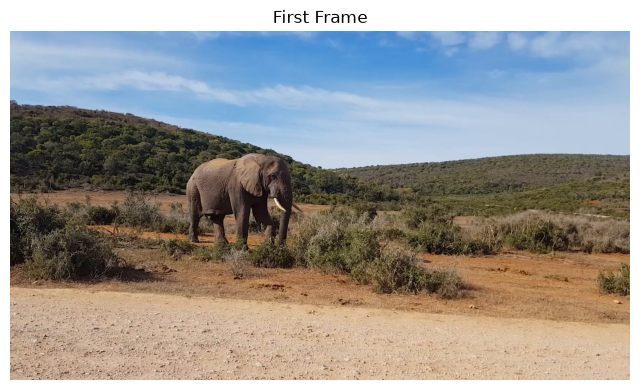

In [5]:
ret, old_frame = cap.read()

if not ret:
    print("Unable to read video")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(old_frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()

In [6]:
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(
    old_gray,
    mask=None,
    **feature_params
)

print("Feature points detected:", len(p0))

Feature points detected: 100


In [8]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

mask = np.zeros_like(old_frame)

In [9]:
ret, frame = cap.read()

frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

p1, status, error = cv2.calcOpticalFlowPyrLK(
    old_gray,
    frame_gray,
    p0,
    None,
    **lk_params
)

good_new = p1[status == 1]
good_old = p0[status == 1]

print("Tracked points:", len(good_new))

Tracked points: 100


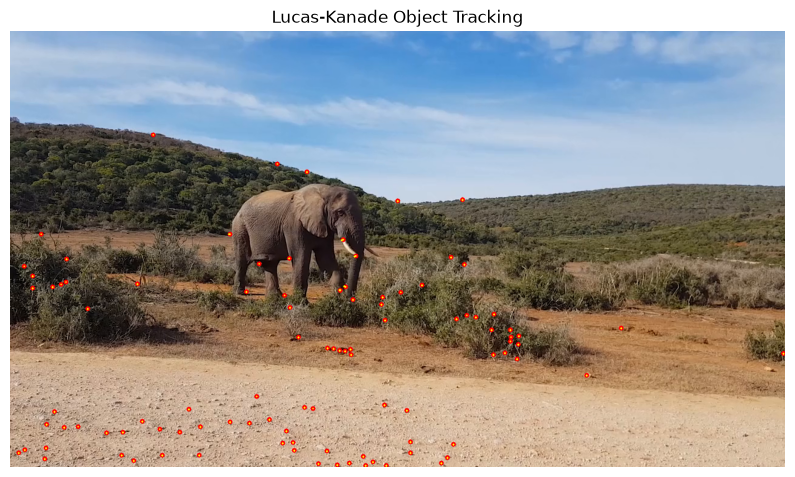

In [10]:
result = frame.copy()

for new, old in zip(good_new, good_old):
    x1, y1 = new.ravel()
    x2, y2 = old.ravel()

    cv2.line(
        mask,
        (int(x2), int(y2)),
        (int(x1), int(y1)),
        (0, 255, 0),
        2
    )

    cv2.circle(
        result,
        (int(x1), int(y1)),
        4,
        (0, 0, 255),
        -1
    )

output = cv2.add(result, mask)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Object Tracking")
plt.axis("off")
plt.show()

In [11]:
displacements = []

for new, old in zip(good_new, good_old):
    dx = new[0] - old[0]
    dy = new[1] - old[1]

    distance = np.sqrt(dx**2 + dy**2)
    displacements.append(distance)

if len(displacements) > 0:
    average_displacement = np.mean(displacements)
    print("Average Displacement:", round(float(average_displacement), 2))
else:
    print("No points tracked")

Average Displacement: 0.61


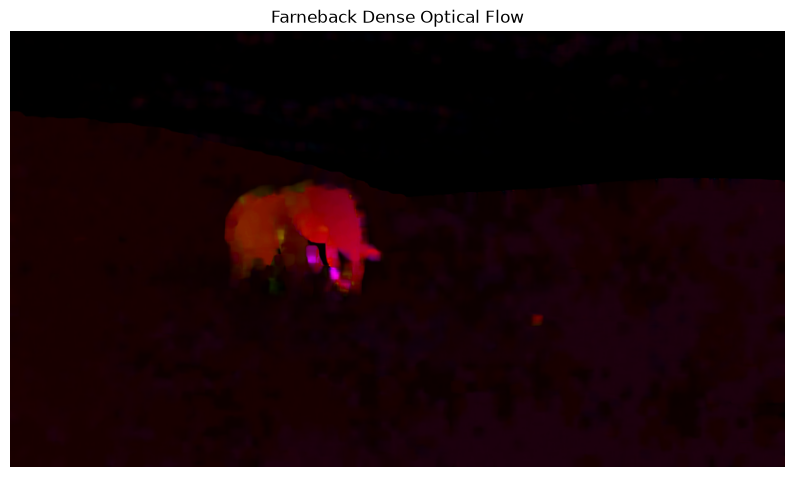

In [12]:
flow = cv2.calcOpticalFlowFarneback(
    old_gray,
    frame_gray,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

hsv = np.zeros_like(frame)
hsv[..., 1] = 255

hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

dense_flow = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(dense_flow)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

In [13]:
print("Optical Flow Tracking Comparison")
print("--------------------------------")
print("Lucas-Kanade : Sparse feature tracking")
print("Farneback    : Dense pixel-wise tracking")
print("Lucas-Kanade : Faster and suitable for selected objects")
print("Farneback    : Provides detailed motion information")

Optical Flow Tracking Comparison
--------------------------------
Lucas-Kanade : Sparse feature tracking
Farneback    : Dense pixel-wise tracking
Lucas-Kanade : Faster and suitable for selected objects
Farneback    : Provides detailed motion information


In [14]:
cap.release()
print("Experiment completed successfully.")

Experiment completed successfully.
